# Redback: Bayesian inference for electromagnetic transients

<img src="notebook_images/RedbackLogo.png" alt="Redback" width="300" align="right"/>

**This notebook** is a self-contained demonstration — run it top-to-bottom or jump to any section. For depth on any topic, links to dedicated example scripts are provided throughout.

**Sections:**
1. [Getting data](#1-getting-data)
2. [Transient objects](#2-transient-objects)
3. [Blackbody & spectral analysis](#3-blackbody--spectral-analysis)
4. [Models as functions](#4-models-as-functions)
5. [Simulation](#5-simulation)
6. [Priors, constraints & likelihoods](#6-priors-constraints--likelihoods)
7. [Inference](#7-inference)
8. [Results](#8-results)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import inspect
import bilby

import redback
from redback.model_library import all_models_dict, modules_dict

22:55 redback INFO    : Loaded plugin module 'redback_surrogates_fiesta' with 4 model(s).
22:55 redback INFO    : Loaded plugin module 'redback_aux_extinction_models' with 1 model(s).
22:55 redback INFO    : Loaded plugin module 'redback_aux_lensing_models' with 10 model(s).
22:55 redback INFO    : Loaded plugin prior provider 'redback_aux_priors'.
22:55 redback INFO    : Loaded plugin prior provider 'csm_priors'.
22:55 bilby INFO    : Running bilby version: 2.7.0.dev70+gcde65c51c.d20260325
22:55 redback INFO    : Running redback version: 1.17.0


---
## 1. Getting data

Redback provides downloaders for several public archives. Data is cached locally after the first download.
See [`getting_data_with_redback.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/getting_data_with_redback.py) for a full tour.


In [7]:
# --- Other downloaders (requires optional packages / network access) ---

# FINK/LASAIR/OAC/OTTER/SWIFT/BATSE

# For this notebook we use pre-existing files in examples/example_data/ or simulated data
print("Available pre-existing example data:")
import os
for f in sorted(os.listdir('example_data')):
    print(" ", f)

Available pre-existing example data:
  .DS_Store
  SN2018ibb_photcat_REDBACK.ascii
  grb_afterglow.csv
  ogip_powerlaw.bak
  ogip_powerlaw.pha
  ogip_powerlaw.rsp


In general, it is as easy as

In [5]:
# --- Swift BAT/XRT: GRB afterglow flux light curve ---
GRB = '070809'
data_grb = redback.get_data.get_bat_xrt_afterglow_data_from_swift(
    grb=GRB, data_mode='flux')
print(f"GRB{GRB}: {len(data_grb)} data points")
display(data_grb.head())

22:57 redback WARNING : You are downloading BAT and XRT data, you will need to truncate the data for some models.
22:57 redback WARNING : The processed data file already exists. Returning.
22:57 redback WARNING : The processed data file already exists. Returning.


GRB070809: 27 data points


,Time [s],Pos. time err [s],Neg. time err [s],Flux [erg cm^{-2} s^{-1}],Pos. flux err [erg cm^{-2} s^{-1}],Neg. flux err [erg cm^{-2} s^{-1}],Instrument
0,0.18,0.06,-0.06,2.762778e-08,6.870867e-09,-6.870867e-09,BAT
1,0.26,0.02,-0.02,8.452583e-08,1.556569e-08,-1.556569e-08,BAT
2,0.32,0.04,-0.04,7.646550e-08,1.625543e-08,-1.625543e-08,BAT
3,0.38,0.02,-0.02,1.772437e-07,3.688727e-08,-3.688727e-08,BAT
4,0.44,0.04,-0.04,1.081433e-07,2.666597e-08,-2.666597e-08,BAT


---
 ## 2. Transient objects

  All data is wrapped into typed transient objects with a consistent interface.
  Available types: `SGRB`, `LGRB`, `Afterglow`, `Kilonova`, `Supernova`, `TDE`, `FXT`, `OpticalTransient`, `Spectrum`, `CountsSpectrumTransient`,
  `PromptTimeSeries`, `Transient`.
  See [`creating_transient_objects.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/creating_transient_objects.py).


Time range: 126.69 – 67308.90 s
Data mode:  flux


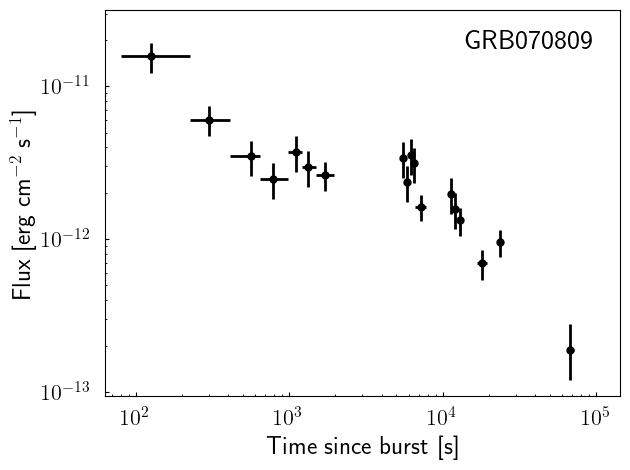

In [10]:
# From Swift — GRB070809 afterglow, converted to luminosity at source
afterglow = redback.afterglow.SGRB.from_swift_grb(
    name='GRB070809', redshift=0.2187,
    data_mode='flux', truncate=True, truncate_method='prompt_time_error')

print(f"Time range: {afterglow.x.min():.2f} – {afterglow.x.max():.2f} s")
print(f"Data mode:  {afterglow.data_mode}")
ax = afterglow.plot_data(save=False, show=True)

23:07 redback WARNING : The data is already in luminosity mode, returning.


Data mode:  luminosity


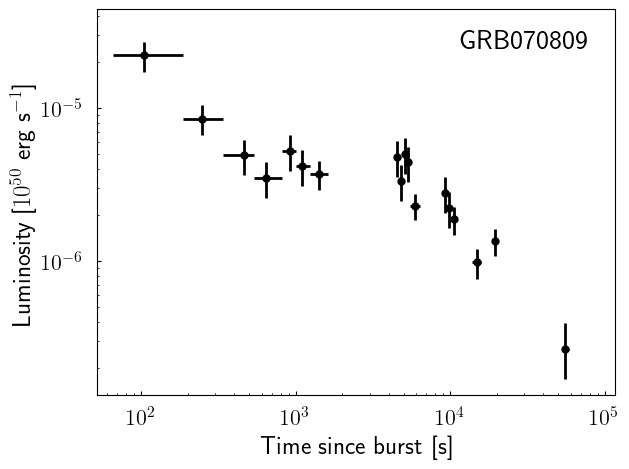

In [15]:
# Use inbuilt methods for easy conversion to luminosity
afterglow.analytical_flux_to_luminosity()
print(f"Data mode:  {afterglow.data_mode}")
ax = afterglow.plot_data(save=False, show=True)

23:07 redback INFO    : Metadata does not exist for this event.
23:07 redback INFO    : Setting metadata to None. This is not an error, but a warning that no metadata could be found online.


Unique frequencies: [3.000e+09 6.000e+09 3.730e+14 5.090e+14 2.418e+17]


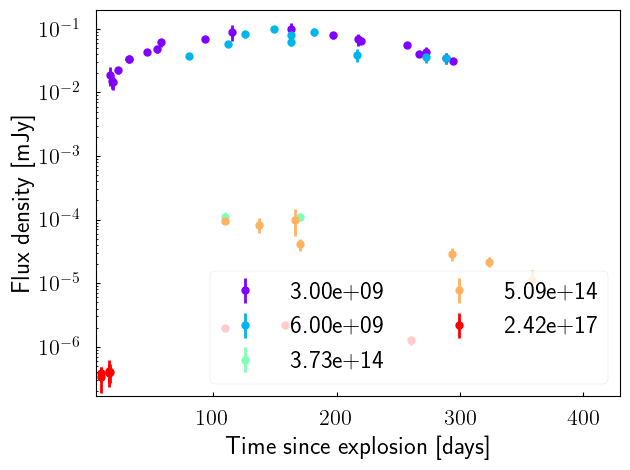

<Axes: xlabel='Time since explosion [days]', ylabel='Flux density [mJy]'>

In [16]:
# From private CSV — broadband GRB170817A afterglow
data = pd.read_csv('example_data/grb_afterglow.csv')
broadband = redback.transient.Afterglow(
    name='GRB170817A_broadband',
    data_mode='flux_density',
    time=data['time'].values,
    flux_density=data['flux'].values,
    flux_density_err=data['flux_err'].values,
    frequency=data['frequency'].values)

print(f"Unique frequencies: {np.unique(broadband.frequency)}")
broadband.plot_data(save=False, show=True)

23:07 redback INFO    : Initializing Supernova transient 'SN2018ibb' with data_mode='magnitude'
23:07 redback INFO    : [Errno 2] No such file or directory: 'supernova//SN2018ibb_metadata.csv'
23:07 redback INFO    : Setting metadata to None. This is not an error, but a warning that no metadata could be found online.


MPG/GROND optical and NIR filters...
done.

NTT/EFOSC2 Gunn filters...
done.

EUCLID optical and IR filters...
done.

Spitzer IRAC filters...
done.

WISE filters...
done.

SN2018ibb: 692 epochs across 14 bands
Bands: ['2massh' '2massj' '2massks' 'gaia::g' 'grond::i' 'grond::z' 'uvot::b'
 'uvot::u' 'uvot::uvm2' 'uvot::uvw1' 'uvot::uvw2' 'uvot::v' 'ztfg' 'ztfr']


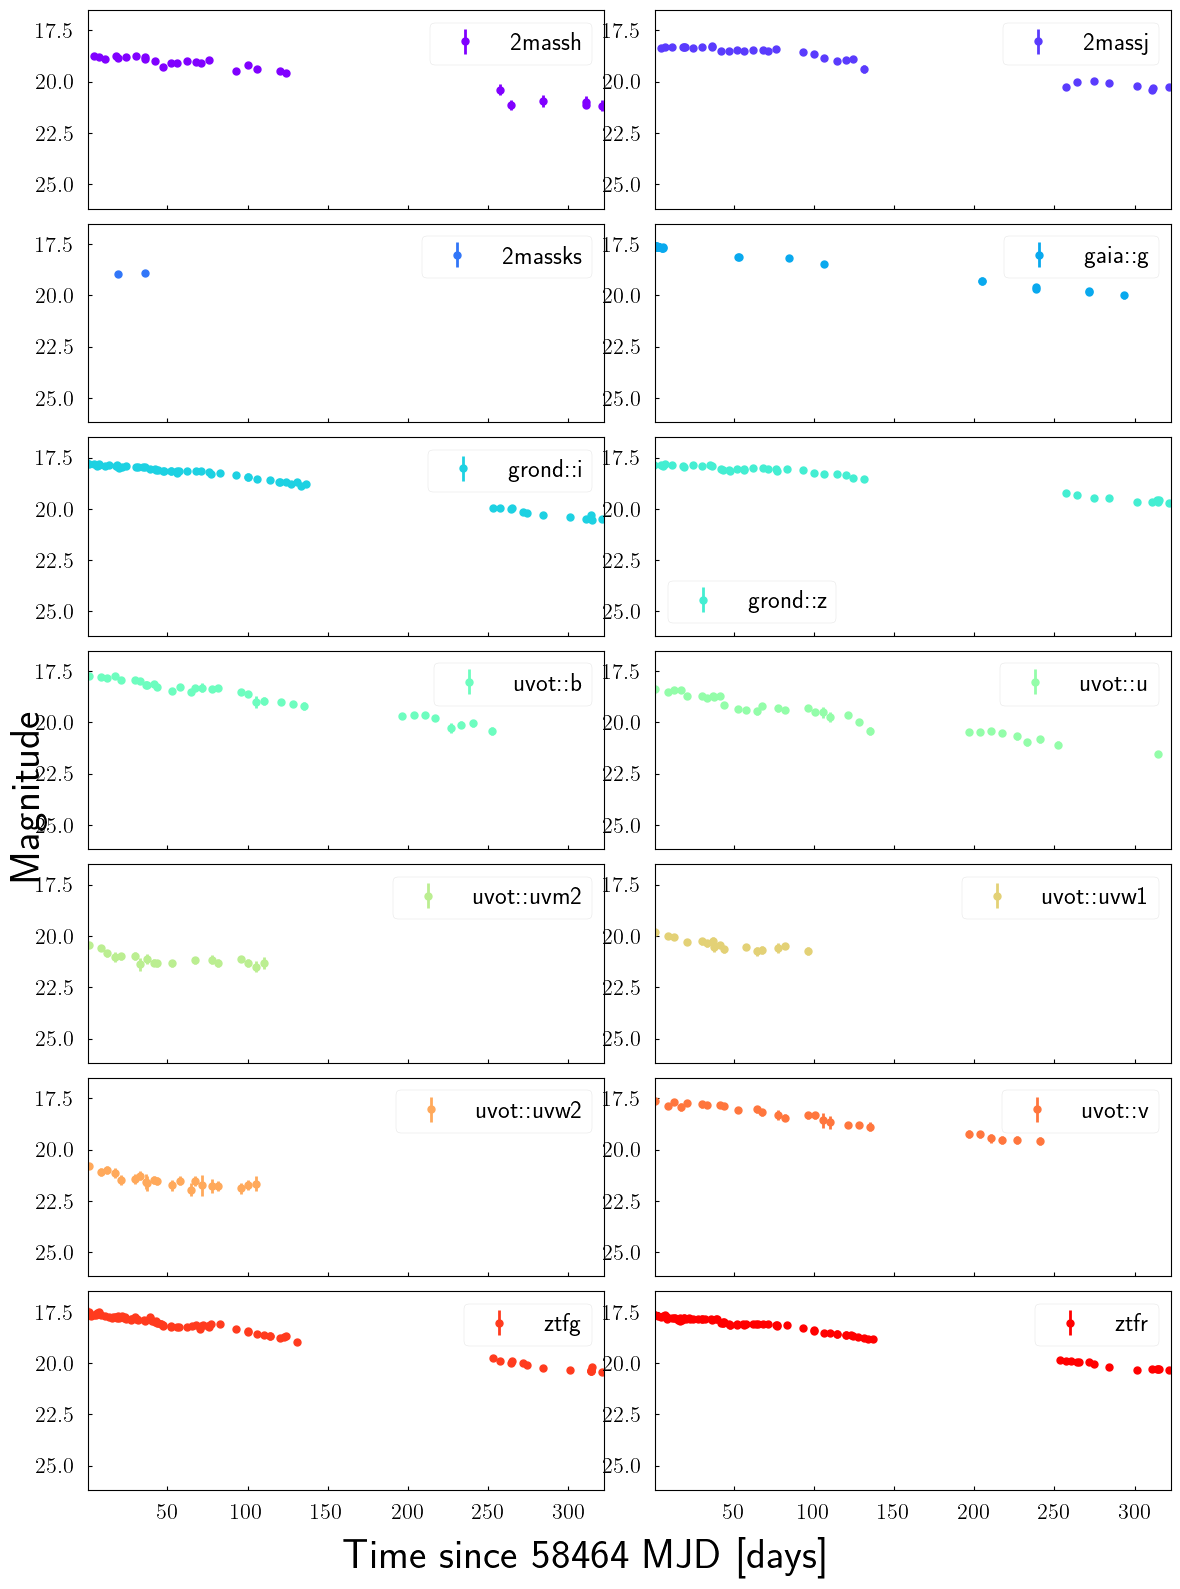

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

In [17]:
# Supernova from ASCII — SN2018ibb
z_sn = 0.166
from redback import filters
filters.add_common_filters()
data_sn = pd.read_csv('example_data/SN2018ibb_photcat_REDBACK.ascii', sep=r'\s+',
    skiprows=1, names=['telescope','instrument','band','MJD','MAG','MAG_ERR'])

# use_phase_model=True keeps time as MJD; pass time_mjd (not time)
supernova = redback.transient.Supernova(
    name='SN2018ibb',
    data_mode='magnitude',
    time_mjd=data_sn['MJD'].values,
    magnitude=data_sn['MAG'].values,
    magnitude_err=data_sn['MAG_ERR'].values,
    bands=data_sn['band'].values,
    redshift=z_sn,
    use_phase_model=True)

print(f"SN2018ibb: {len(supernova.x)} epochs across {len(supernova.unique_bands)} bands")
print("Bands:", supernova.unique_bands)
supernova.plot_multiband(save=False, show=True)

In [25]:
redback.plotting.MagnitudePlotter?

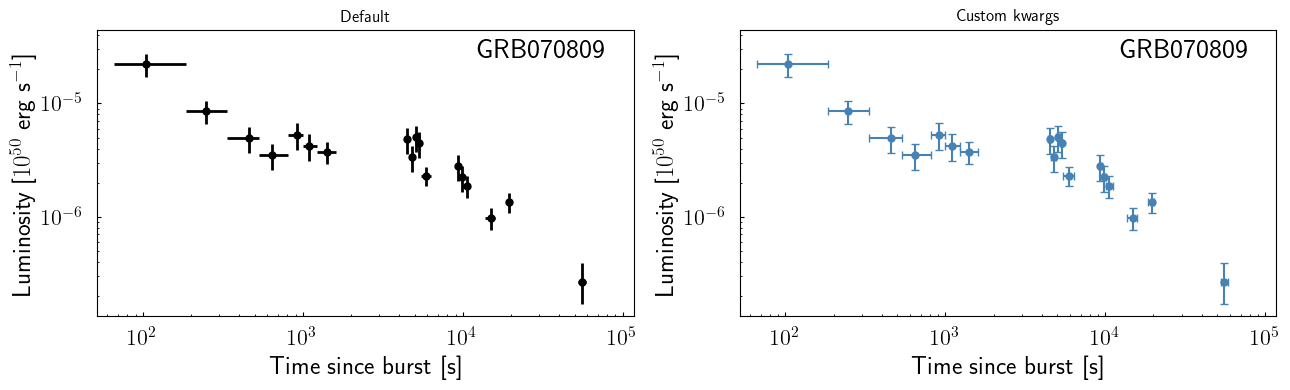

In [26]:
# --- Plot customisation — all plot methods accept matplotlib kwargs ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Default style
afterglow.plot_data(save=False, show=False, axes=axes[0])
axes[0].set_title('Default')

# Customised
afterglow.plot_data(save=False, show=False, axes=axes[1],
                    color='steelblue', marker='s', markersize=5,
                    capsize=3, elinewidth=1.5)
axes[1].set_title('Custom kwargs')

plt.tight_layout()
plt.show()

Detections: 15, Upper limits: 5


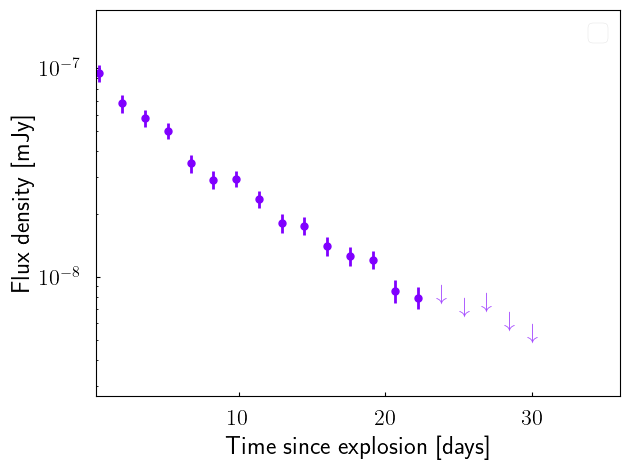

<Axes: xlabel='Time since explosion [days]', ylabel='Flux density [mJy]'>

In [27]:
# --- Upper limits / non-detections ---
# Pass detections=bool array; False → plotted as upper-limit arrows
np.random.seed(42)
t_ul = np.linspace(0.5, 30, 20)
func_ul = all_models_dict['magnetar_only']
fd_true = func_ul(t_ul, l0=1e-7, tau=10., nn=3.)
sigmas = 0.1 * fd_true
fd_obs = fd_true + np.random.normal(0, sigmas)

detections = np.ones(len(t_ul), dtype=bool)
detections[-5:] = False   # last 5 are upper limits

transient_ul = redback.transient.SGRB(
    name='demo_upper_limits',
    data_mode='flux_density',
    time=t_ul,
    flux_density=fd_obs,
    flux_density_err=sigmas,
    detections=detections)

print(f"Detections: {detections.sum()}, Upper limits: {(~detections).sum()}")
transient_ul.plot_data(save=False, show=True)

---
## 3. Blackbody & spectral analysis

Fit a Planck or modified SED at each epoch to estimate temperature, radius and bolometric luminosity.
See [`estimating_blackbody_properties_with_redback.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/estimating_blackbody_properties_with_redback.ipynb)
and [`estimating_lbols.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/estimating_lbols.ipynb) for in-depth demos.


In [29]:
from astropy.cosmology import Planck18 as cosmo

distance_sn = cosmo.luminosity_distance(z_sn).cgs.value  # cm

# Standard blackbody
bb_params_standard = supernova.estimate_bb_params(
    distance=distance_sn, method="blackbody")

# Cutoff blackbody — adds an exponential UV suppression term
bb_params_cutoff = supernova.estimate_bb_params(
    distance=distance_sn, method="cutoff_blackbody")

# Compare temperature and radius between the two methods
df_bb = pd.DataFrame({
    "MJD": bb_params_standard["epoch_times"],
    "T_BB [K]": bb_params_standard["temperature"],
    "T_cutoff [K]": bb_params_cutoff["temperature"],
    "R_BB [cm]": bb_params_standard["radius"],
})
print(df_bb.head(6).to_string(index=False))
T_std_peak = bb_params_standard["temperature"].max()
T_cut_peak = bb_params_cutoff["temperature"].max()
print(f"Peak temperature (standard):  {T_std_peak:.0f} K")
print(f"Peak temperature (cutoff):    {T_cut_peak:.0f} K")

23:10 redback INFO    : Estimating blackbody parameters for SN2018ibb.
23:10 redback INFO    : Using data mode = magnitude
23:10 redback INFO    : Number of bins: 933
23:10 redback INFO    : Masking epochs with likely wrong extractions
23:10 redback INFO    : Estimating cutoff blackbody parameters for SN2018ibb.
23:10 redback INFO    : Using data mode = magnitude
23:10 redback WARNING : Using effective wavelength approximation for cutoff_blackbody fits in magnitude mode.
23:10 redback INFO    : Number of bins: 933
23:10 redback INFO    : Masking epochs with likely wrong cutoff blackbody extractions


         MJD     T_BB [K]  T_cutoff [K]    R_BB [cm]
58387.499000 10558.868587  10386.731385 3.682615e+15
58422.414000 13225.250089  12982.155752 3.344868e+15
58423.370750 11438.640039  11311.458818 4.041817e+15
58424.351333 10875.864780  10766.990473 4.479614e+15
58425.403800 11843.652877  11688.237084 3.904314e+15
58426.384000 12231.694741  12074.192960 3.755977e+15
Peak temperature (standard):  14329 K
Peak temperature (cutoff):    14224 K


23:15 redback INFO    : No lambda_cut provided; no correction applied. Assuming a pure blackbody SED.
23:15 redback INFO    : Estimating blackbody parameters for SN2018ibb.
23:15 redback INFO    : Using data mode = magnitude
23:15 redback INFO    : Number of bins: 933
23:15 redback INFO    : Masking epochs with likely wrong extractions
23:15 redback INFO    : Masking bolometric estimates with likely wrong extractions
23:15 redback INFO    : Estimated bolometric luminosity using blackbody integration.
23:15 redback INFO    : Initializing Supernova transient 'sn2018ibb_bolometric' with data_mode='luminosity'
23:15 redback INFO    : [Errno 2] No such file or directory: 'supernova//sn2018ibb_bolometric_metadata.csv'
23:15 redback INFO    : Setting metadata to None. This is not an error, but a warning that no metadata could be found online.


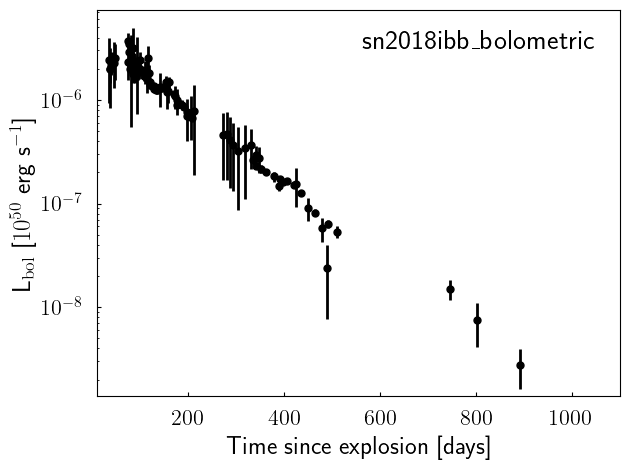

<Axes: xlabel='Time since explosion [days]', ylabel='L$_{\\rm bol}$ [$10^{50}$ erg s$^{-1}$]'>

In [41]:
# Bolometric luminosity from SED integration
df_lbol = supernova.estimate_bolometric_luminosity(
    distance=distance_sn, binning_method="mean", bin_size=3.)

sn = redback.transient.Supernova(name='sn2018ibb_bolometric', 
                                 data_mode='luminosity', 
                                 time_rest_frame=df_lbol['epoch_times'].values - df_lbol['epoch_times'].iloc[0], 
                                Lum50=df_lbol["lum_bol"].values, Lum50_err=df_lbol["lum_bol_err"].values)
sn.plot_data(xlim_low=10, xscale='linear', xlim_high=1100)

23:23 redback INFO    : Loading default spectral templates from sncosmo
23:23 redback INFO    : Generated 34 sncosmo templates
23:23 redback INFO    : Loaded 34 templates into the matcher


Top matches:
  {'type': 'Ia', 'phase': -5.0, 'redshift': 0.01, 'rlap': 8.42232291122117, 'correlation': 0.9881621188320127, 'template_name': 'salt2_Ia_phase-5', 'template_source': 'salt2', 'n_valid_points': 410}


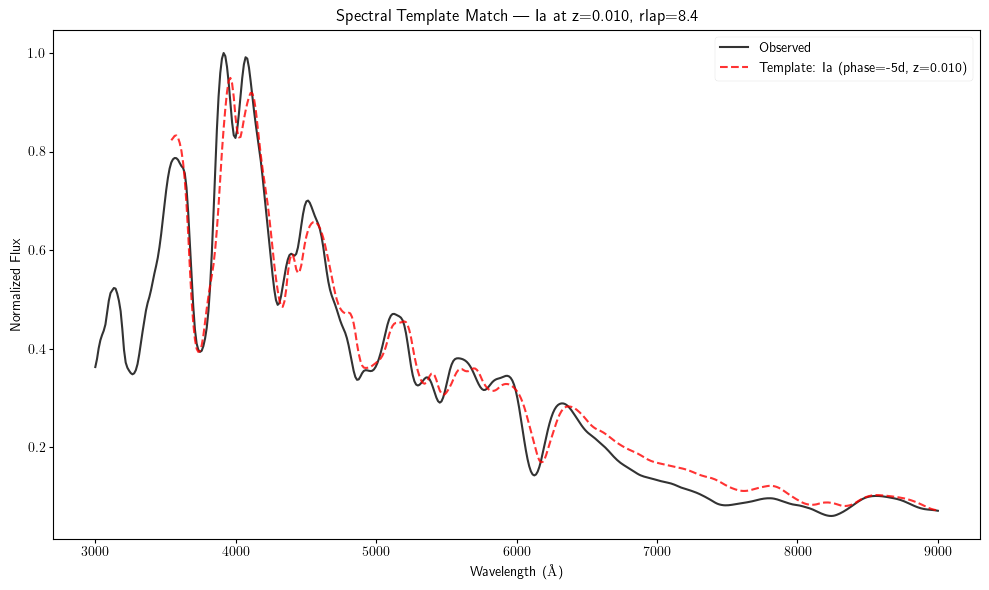

In [51]:
import sncosmo
from redback.analysis import SpectralTemplateMatcher
from redback.transient import Spectrum

# Use a real Hsiao SN Ia template at peak as the observed spectrum
source = sncosmo.get_source('hsiao', version='3.0')
wave = np.linspace(3000, 9000, 500)
flux_spec = source.flux(0.0, wave)  # phase=0 = maximum light
flux_err = 0.02 * flux_spec.max() * np.ones_like(flux_spec)

spectrum = Spectrum(angstroms=wave, flux_density=flux_spec, flux_density_err=flux_err)

matcher = SpectralTemplateMatcher()
matches = matcher.match_spectrum(
  spectrum=spectrum,
  redshift_range=(0.01, 0.05),
  n_redshift_points=20)
print('Top matches:')
if matches:
    for m in (matches[:5] if isinstance(matches, list) else [matches]):
        print(f'  {m}')
else:
    print('  No matches above threshold')

fig, ax = plt.subplots(figsize=(10, 6))
matcher.plot_match(spectrum, matches, axes=ax)
ax.set_title(
    f"Spectral Template Match  —  "
    f"{matches['type']} at z={matches['redshift']:.3f}, rlap={matches['rlap']:.1f}"
)
plt.tight_layout()

---
## 4. Models as functions

Every redback model is a plain Python callable — use directly for exploration, comparison, or as a likelihood component.
See [`fit_your_own_model_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/fit_your_own_model_example.py).


In [53]:
 # Full model inventory — public callable models only
public_models = {k: v for k, v in all_models_dict.items() if not k.startswith('_')}
print(f"Total public models in redback: {len(public_models)}")
print()
for category, model_list in sorted(modules_dict.items()):
    public = [m for m in model_list if not m.startswith('_') and m in public_models]
    if public:
        print(f"  {category:<30s} {len(public):>4d} models")

Total public models in redback: 547

  afterglow_models                 41 models
  combined_models                  11 models
  csm_models                      211 models
  extinction_models                15 models
  fireball_models                   3 models
  gaussianprocess_models            1 models
  general_synchrotron_models       17 models
  integrated_flux_afterglow_models    5 models
  kilonova_models                  85 models
  magnetar_driven_ejecta_models    23 models
  magnetar_models                  25 models
  phase_models                     14 models
  phenomenological_models          20 models
  prompt_models                     5 models
  redback_aux_extinction_models     1 models
  redback_aux_lensing_models       10 models
  redback_aux_models                3 models
  redback_surrogates_fiesta         4 models
  shock_powered_models             20 models
  spectral_models                  23 models
  stellar_interaction_models        8 models
  supernova_mode

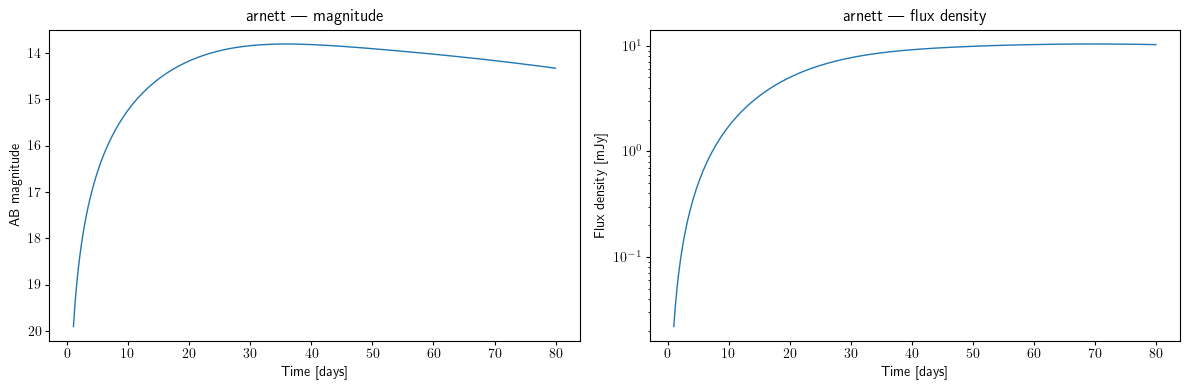

Text(0, 0.5, 'Flux [erg/s/cm2/Ang]')

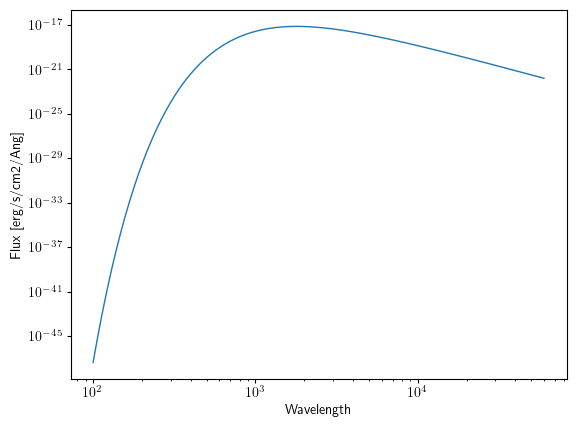

In [71]:
# Call a model directly — same function, different output formats
arnett = all_models_dict['arnett']

t = np.linspace(1, 80, 300)
base_params = dict(kappa=0.1, kappa_gamma=10., mej=3.0, vej=8000,
                   temperature_floor=3000, f_nickel=0.5, redshift=0.01)

# Magnitude output
mags = arnett(t, **base_params, output_format='magnitude', bands='ztfr')

# Flux density output
fds  = arnett(t, **base_params, output_format='flux_density', frequency=3e14)

# Spectra
specs  = arnett(t, **base_params, output_format='spectra')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(t, mags); ax1.invert_yaxis()
ax1.set(xlabel='Time [days]', ylabel='AB magnitude', title='arnett — magnitude')
ax2.semilogy(t, fds)
ax2.set(xlabel='Time [days]', ylabel='Flux density [mJy]', title='arnett — flux density')
plt.tight_layout(); plt.show()

plt.loglog(specs.lambdas, specs.spectra[10])
plt.xlabel('Wavelength')
plt.ylabel('Flux [erg/s/cm2/Ang]')

Some models have extra output available which can be useful for debugging/physical interpretation etc

Available fields: ('bolometric_luminosity', 'photosphere_temperature', 'photosphere_radius', 'lum_xray', 'accretion_radius', 'SMBH_accretion_rate', 'time_temp', 'nulnu', 'time_since_fb', 'tfb', 'lnu', 'envelope_radius', 'envelope_mass', 'rtidal', 'rcirc', 'termination_time', 'termination_time_id', 'f_debris', 'f_mbh', 'g_mstar', 'scaling_factor')


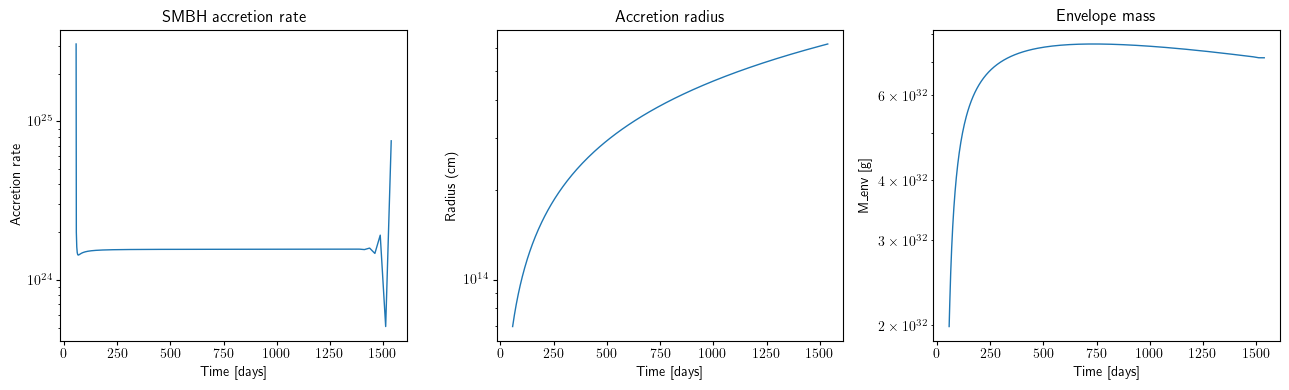

In [103]:
from redback.transient_models.tde_models import _cooling_envelope

# mbh_6: BH mass in units of 1e6 Msun, stellar_mass: Msun, eta, alpha, beta
out = _cooling_envelope(mbh_6=1.0, stellar_mass=1.0, eta=0.1, alpha=0.5, beta=10.0)

print("Available fields:", out._fields)

t_days = out.time_temp / 86400

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].semilogy(t_days, out.SMBH_accretion_rate)
axes[0].set(xlabel='Time [days]', ylabel='Accretion rate', title='SMBH accretion rate')
axes[1].semilogy(t_days, out.accretion_radius)
axes[1].set(xlabel='Time [days]', ylabel='Radius (cm)', title='Accretion radius')
axes[2].semilogy(t_days, out.envelope_mass)
axes[2].set(xlabel='Time [days]', ylabel='M_env [g]', title='Envelope mass')
plt.tight_layout()
plt.show()

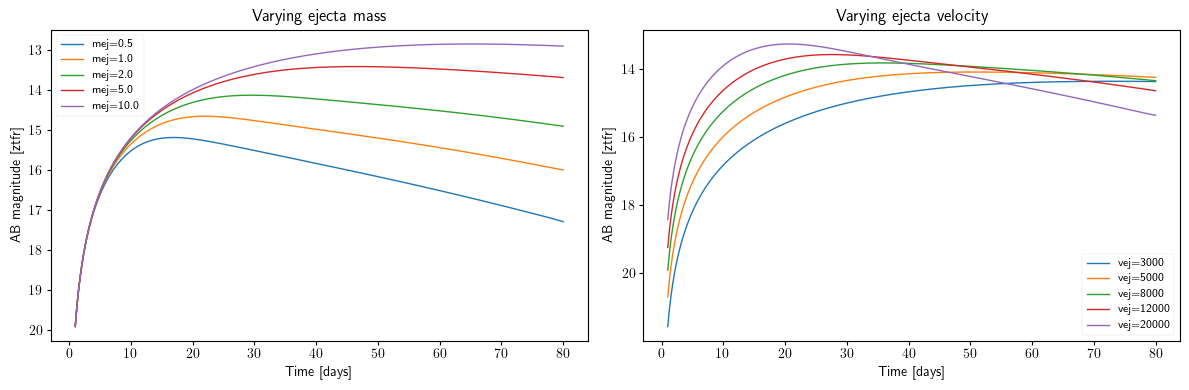

In [72]:
# Parameter exploration — vary ejecta mass and velocity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for mej in [0.5, 1.0, 2.0, 5.0, 10.0]:
    mag = arnett(t, **{**base_params, 'mej': mej},
                 output_format='magnitude', bands=np.full(len(t), 'ztfr'))
    axes[0].plot(t, mag, label=f'mej={mej}')

for vej in [3000, 5000, 8000, 12000, 20000]:
    mag = arnett(t, **{**base_params, 'vej': vej},
                 output_format='magnitude', bands=np.full(len(t), 'ztfr'))
    axes[1].plot(t, mag, label=f'vej={vej}')

for ax, title in zip(axes, ['Varying ejecta mass', 'Varying ejecta velocity']):
    ax.invert_yaxis()
    ax.set(xlabel='Time [days]', ylabel='AB magnitude [ztfr]', title=title)
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

---
## 5. Simulation

Redback provides multiple simulation classes with increasing realism:

| Class | Description |
|-------|-------------|
| `SimulateGenericTransient` | Custom time grid, any model, pure noise |
| `SimulateOpticalTransient.simulate_transient` | Custom pointings table, SNR cuts |
| `SimulateOpticalTransient.simulate_transient_in_ztf` | Real ZTF pointing database |
| `SimulateOpticalTransient.simulate_transient_population_in_rubin` | Full Rubin LSST survey |
| `PopulationSynthesizer` | Prior-based population forward model |

See [`simulate_basic_transient.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_basic_transient.py),
[`simulate_kilonova.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_kilonova.py),
[`simulate_kilonova_population.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_kilonova_population.py),
[`ToOSimulations_with_redback.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/ToOSimulations_with_redback.ipynb).


In [73]:
# --- 5a. Generic simulation — custom time grid, any model ---
from redback.simulate_transients import SimulateGenericTransient, SimulateOpticalTransient

bands_generic = ['lsstg', 'lsstr', 'lssti']
times_generic = np.linspace(0.2, 10, 20)  # days

kn_generic = SimulateGenericTransient(
    model='one_component_kilonova_model',
    parameters=dict(mej=0.05, redshift=0.01, temperature_floor=3000, kappa=1.0, vej=0.2),
    times=times_generic,
    data_points=40,
    model_kwargs=dict(bands=bands_generic, output_format='magnitude'),
    multiwavelength_transient=True,
    noise_term=0.05)

print("Generated data shape:", kn_generic.data.shape)
print(kn_generic.data.head(8))

Generated data shape: (40, 5)
       time   band  true_output     output  output_error
0  0.200000  lssti    20.388652  19.086612      1.019433
1  0.715789  lsstr    19.106529  17.626939      0.955326
2  0.715789  lsstg    19.518087  20.734383      0.975904
3  0.715789  lssti    18.971580  18.851290      0.948579
4  1.231579  lssti    18.626564  19.324411      0.931328
5  1.231579  lsstr    18.922279  18.243643      0.946114
6  1.747368  lssti    18.590768  20.131002      0.929538
7  1.747368  lsstg    19.940390  18.404563      0.997020


23:38 redback INFO    : Initializing Kilonova transient 'generic_kn' with data_mode='magnitude'
23:38 redback INFO    : [Errno 2] No such file or directory: 'kilonova//generic_kn_metadata.csv'
23:38 redback INFO    : Setting metadata to None. This is not an error, but a warning that no metadata could be found online.


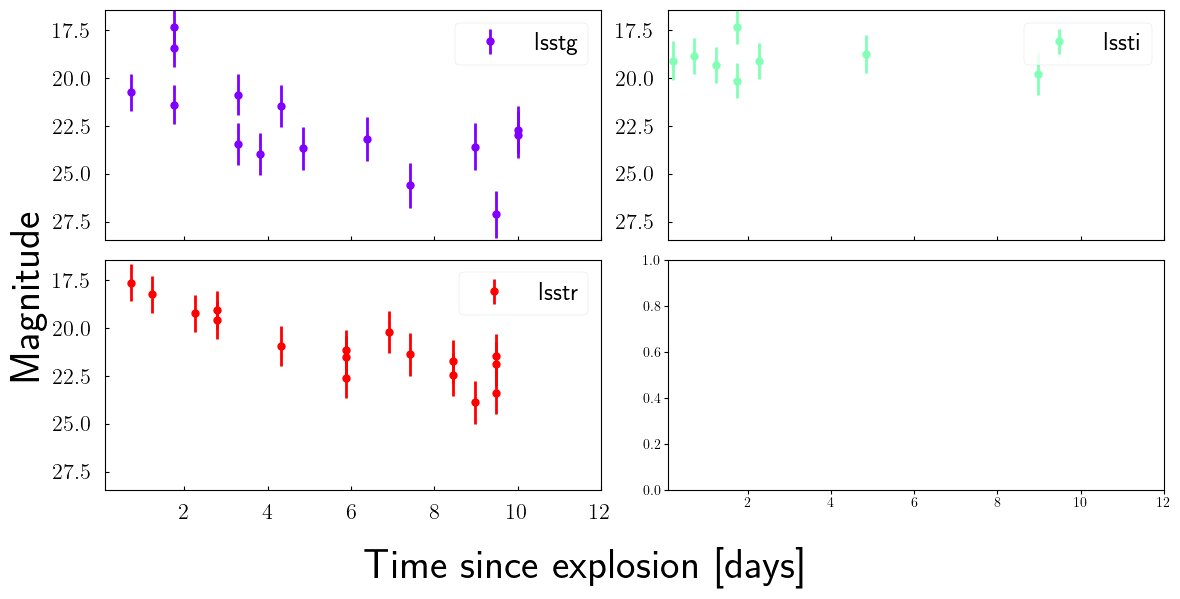

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

In [74]:
# Load generic simulation into a transient object and plot
kn_obj = redback.transient.Kilonova(
    name='generic_kn',
    data_mode='magnitude',
    magnitude=kn_generic.data['output'].values,
    magnitude_err=kn_generic.data['output_error'].values,
    time=kn_generic.data['time'].values,
    bands=kn_generic.data['band'].values)

kn_obj.plot_multiband(save=False, show=True)

In [75]:
# --- 5b. ZTF simulation — real pointing database, SNR cuts ---
np.random.seed(42)
params_ztf = dict(
    mej=3.0, f_nickel=0.8, kappa=0.1, kappa_gamma=10.,
    vej=8000, temperature_floor=3000, redshift=0.01,
    t0_mjd_transient=59000.0,
    ra=3.355395, dec=0.5820673)   # known ZTF-covered position

sim_ztf = SimulateOpticalTransient.simulate_transient_in_ztf(
    model="arnett", parameters=params_ztf, model_kwargs={},
    end_transient_time=80., snr_threshold=5.)

total    = len(sim_ztf.observations)
detected = sim_ztf.observations["detected"].sum()
print(f"ZTF: {total} epochs scheduled, {detected} detected (SNR >= 5)")
print(sim_ztf.observations[["time","band","magnitude","e_magnitude","detected"]].head(10))

23:38 redback INFO    : Using ztf.tar.gz as the pointing database corresponding to ztf.


ZTF: 130 epochs scheduled, 124.0 detected (SNR >= 5)
           time  band  magnitude  e_magnitude  detected
0  58997.164062  ztfg  23.296804     3.197144       0.0
1  58997.167969  ztfg  24.839461     3.182188       0.0
2  58997.250000  ztfr  23.452229     3.250826       0.0
3  58997.257812  ztfr  22.828862     3.007615       0.0
4  59000.230469  ztfg  22.808544     1.184099       0.0
5  59000.261719  ztfg  22.404603     0.748824       0.0
6  59004.195312  ztfg  16.325957     0.004545       1.0
7  59004.195312  ztfg  16.329743     0.004396       1.0
8  59004.234375  ztfr  16.641350     0.005319       1.0
9  59004.234375  ztfr  16.636305     0.004696       1.0


23:38 redback INFO    : Filtered 6 non-detections, 124 detections remain
23:38 redback INFO    : Initializing Supernova transient 'tutorial_arnett_ztf' with data_mode='magnitude'
23:38 redback INFO    : [Errno 2] No such file or directory: 'supernova//tutorial_arnett_ztf_metadata.csv'
23:38 redback INFO    : Setting metadata to None. This is not an error, but a warning that no metadata could be found online.


Detected bands: ['ztfg' 'ztfi' 'ztfr']


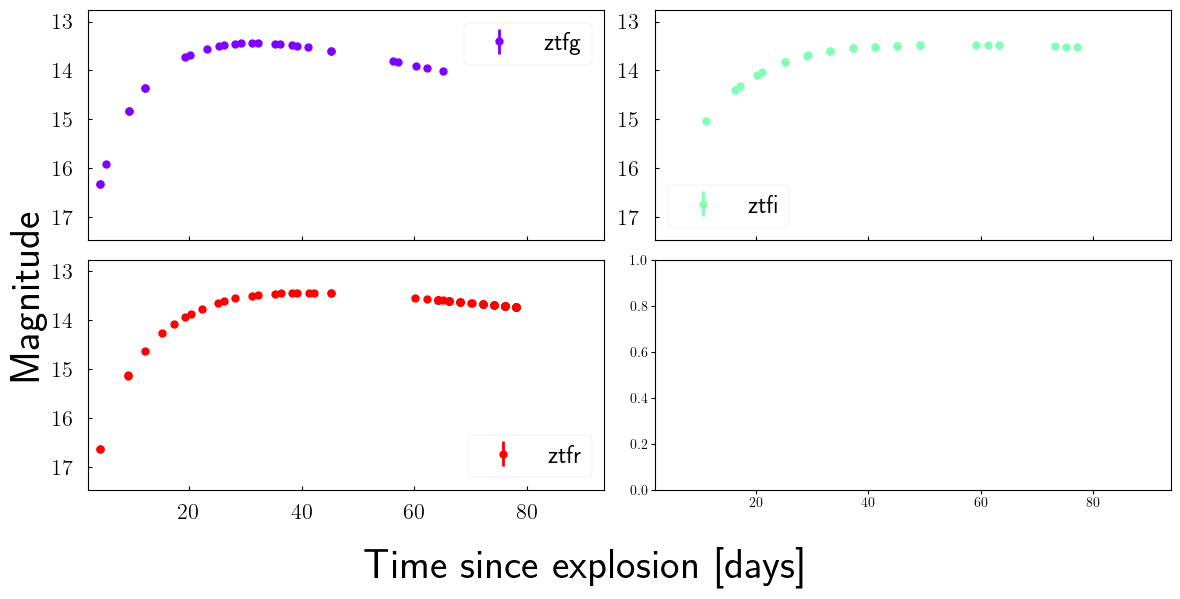

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

In [76]:
# Save and load as a redback transient
sim_ztf.save_transient(name='tutorial_arnett_ztf')
sn_ztf = redback.transient.Supernova.from_simulated_optical_data(
    name='tutorial_arnett_ztf', data_mode='magnitude')

print(f"Detected bands: {sn_ztf.unique_bands}")
sn_ztf.plot_multiband(save=False, show=True)

In [77]:
# --- 5c. Rubin population simulation — full survey pointing database ---
import bilby
np.random.seed(42)

prior_rubin = redback.priors.get_priors(model='one_component_kilonova_model')
prior_rubin['redshift'] = bilby.core.prior.Uniform(0.0001, 0.002, 'redshift')

n_events = 3
pop_params = prior_rubin.sample(n_events)
pop_params['t0_mjd_transient'] = np.array([60260., 60280., 60290.])

kn_pop = SimulateOpticalTransient.simulate_transient_population_in_rubin(
    model='one_component_kilonova_model',
    survey='Rubin_10yr_baseline',
    parameters=pop_params,
    model_kwargs={},
    end_transient_time=20.,
    snr_threshold=5.)

kn_pop.save_transient_population(transient_names=None)

n_detected_total = sum(len(df) for df in kn_pop.list_of_inference_observations)
print(f"Rubin: {n_events} events → {n_detected_total} detected observations total")

23:39 redback INFO    : Using rubin_baseline_v3.0_10yrs.tar.gz as the pointing database corresponding to Rubin_10yr_baseline.


Rubin: 3 events → 47 detected observations total


23:39 redback INFO    : Filtered 5 non-detections, 23 detections remain
23:39 redback INFO    : Initializing Kilonova transient 'event_0' with data_mode='magnitude'
23:39 redback INFO    : [Errno 2] No such file or directory: 'kilonova//event_0_metadata.csv'
23:39 redback INFO    : Setting metadata to None. This is not an error, but a warning that no metadata could be found online.
23:39 redback INFO    : Filtered 7 non-detections, 13 detections remain
23:39 redback INFO    : Initializing Kilonova transient 'event_1' with data_mode='magnitude'
23:39 redback INFO    : [Errno 2] No such file or directory: 'kilonova//event_1_metadata.csv'
23:39 redback INFO    : Setting metadata to None. This is not an error, but a warning that no metadata could be found online.


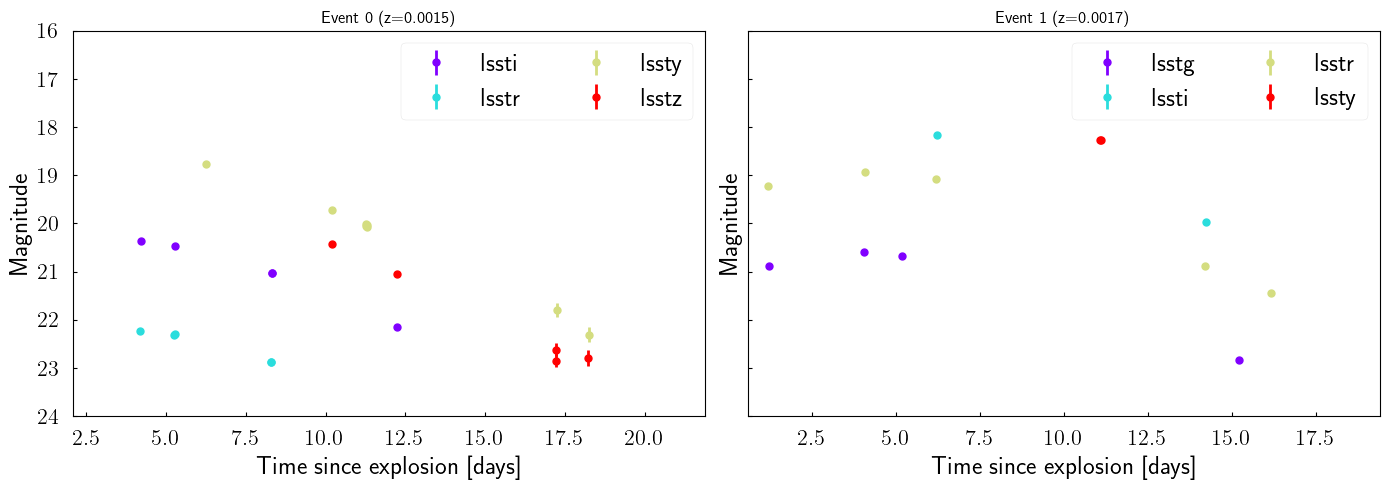

Plotted 2 events with detections


In [78]:
# Load and plot the Rubin-detected events
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plotted = 0
for i in range(n_events):
    try:
        kne = redback.transient.Kilonova.from_simulated_optical_data(
            name=f'event_{i}', data_mode='magnitude')
        if len(kne.x) == 0:
            continue
        kne.plot_data(axes=axes[plotted], data_mode='magnitude',
                      show=False, save=False)
        axes[plotted].set_title(f'Event {i} (z={pop_params["redshift"][i]:.4f})')
        plotted += 1
        if plotted == 2:
            break
    except Exception:
        pass

plt.ylim(24, 16)
plt.tight_layout()
plt.show()
print(f"Plotted {plotted} events with detections")

23:47 redback INFO    : Using the supplied as the pointing database.
23:47 redback INFO    : Filtered 0 non-detections, 12 detections remain
23:47 redback INFO    : Initializing Kilonova transient 'tutorial_kn_cadence' with data_mode='magnitude'
23:47 redback INFO    : [Errno 2] No such file or directory: 'kilonova//tutorial_kn_cadence_metadata.csv'
23:47 redback INFO    : Setting metadata to None. This is not an error, but a warning that no metadata could be found online.


Custom cadence: 12 scheduled, 12.0 detected


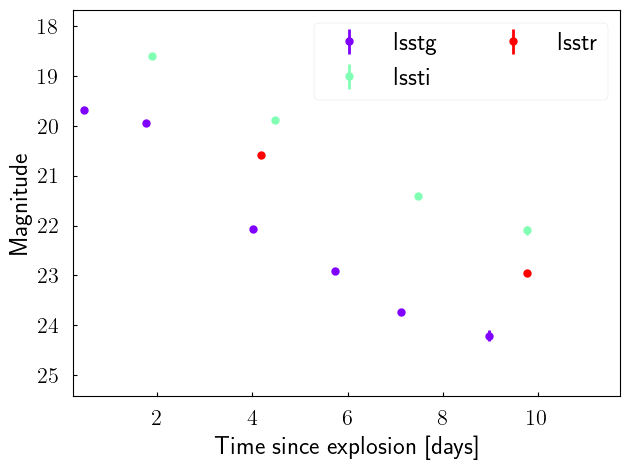

<Axes: xlabel='Time since explosion [days]', ylabel='Magnitude'>

In [104]:
# --- 5d. Custom pointings table — bridge between generic and full survey ---
pointings = redback.simulate_transients.make_pointing_table_from_average_cadence(
    ra=1.0, dec=1.5,
    num_obs={'lsstg': 15, 'lsstr': 15, 'lssti': 10},
    average_cadence={'lsstg': 1.5, 'lsstr': 5.0, 'lssti': 2.5},
    cadence_scatter={'lsstg': 0.3, 'lsstr': 0.3, 'lssti': 0.3},
    limiting_magnitudes={'lsstg': 25.0, 'lsstr': 24.5, 'lssti': 23.0},
    initMJD=59581.0)

params_cadence = dict(mej=0.05, temperature_floor=3000, kappa=1.0, vej=0.2,
                      redshift=0.01, t0_mjd_transient=59582.0, ra=1.0, dec=1.5)
params_cadence['t0'] = params_cadence['t0_mjd_transient']

sim_cadence = SimulateOpticalTransient.simulate_transient(
    model='one_component_kilonova_model',
    parameters=params_cadence,
    pointings_database=pointings,
    survey=None, model_kwargs={},
    end_transient_time=10., snr_threshold=5.)

sim_cadence.save_transient(name='tutorial_kn_cadence')
kn_cadence = redback.transient.Kilonova.from_simulated_optical_data(
    name='tutorial_kn_cadence', data_mode='magnitude')

print(f"Custom cadence: {len(sim_cadence.observations)} scheduled, "
      f"{sim_cadence.observations['detected'].sum()} detected")
kn_cadence.plot_data(save=False, show=True)

---
## 6. Priors, constraints & likelihoods

Redback ships default bilby `PriorDict` objects for every model, with built-in constraint priors to reject unphysical samples, and several likelihood choices for robust fitting.

See [`calling_a_model_with_inbuilt_constraints.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/calling_a_model_with_inbuilt_constraints.py),
[`non_detection_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/non_detection_example.py),
[`MixtureModelLikelihoods.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/MixtureModelLikelihoods.py),
[`handling_non_detections.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/handling_non_detections.ipynb).


In [82]:
# Default prior for any model
prior = redback.priors.get_priors(model='arnett')
prior

{'redshift': Uniform(minimum=0.001, maximum=3, name='redshift', latex_label='$z$', unit=None, boundary=None),
 'f_nickel': LogUniform(minimum=0.001, maximum=1, name='f_nickel', latex_label='$f_{\\mathrm{Ni}}$', unit=None, boundary=None),
 'mej': LogUniform(minimum=0.0001, maximum=100, name='mej', latex_label='$M_{\\mathrm{ej}}~(M_\\odot)$', unit=None, boundary=None),
 'vej': LogUniform(minimum=1000.0, maximum=100000.0, name='vej', latex_label='$v_{\\mathrm{ej}}~(\\mathrm{km}/\\mathrm{s})$', unit=None, boundary=None),
 'kappa': Uniform(minimum=0.05, maximum=2, name='kappa', latex_label='$\\kappa~(\\mathrm{cm}^{2}/\\mathrm{g})$', unit=None, boundary=None),
 'kappa_gamma': LogUniform(minimum=0.0001, maximum=10000.0, name='kappa_gamma', latex_label='$\\kappa_{\\gamma}~(\\mathrm{cm}^{2}/\\mathrm{g})$', unit=None, boundary=None),
 'temperature_floor': LogUniform(minimum=1000.0, maximum=100000.0, name='temperature_floor', latex_label='$T_{\\mathrm{floor}}~(\\mathrm{K})$', unit=None, boundary=

In [84]:
# Modify priors — treat like a regular dict
from bilby.core.prior import Uniform, LogUniform

custom_prior = redback.priors.get_priors(model='arnett')
custom_prior['mej']   = LogUniform(minimum=0.1, maximum=30., name='mej')
custom_prior['redshift'] = 0.01   # fixed value

print("Modified prior:")
custom_prior

Modified prior:


{'redshift': 0.01,
 'f_nickel': LogUniform(minimum=0.001, maximum=1, name='f_nickel', latex_label='$f_{\\mathrm{Ni}}$', unit=None, boundary=None),
 'mej': LogUniform(minimum=0.1, maximum=30.0, name='mej', latex_label='mej', unit=None, boundary=None),
 'vej': LogUniform(minimum=1000.0, maximum=100000.0, name='vej', latex_label='$v_{\\mathrm{ej}}~(\\mathrm{km}/\\mathrm{s})$', unit=None, boundary=None),
 'kappa': Uniform(minimum=0.05, maximum=2, name='kappa', latex_label='$\\kappa~(\\mathrm{cm}^{2}/\\mathrm{g})$', unit=None, boundary=None),
 'kappa_gamma': LogUniform(minimum=0.0001, maximum=10000.0, name='kappa_gamma', latex_label='$\\kappa_{\\gamma}~(\\mathrm{cm}^{2}/\\mathrm{g})$', unit=None, boundary=None),
 'temperature_floor': LogUniform(minimum=1000.0, maximum=100000.0, name='temperature_floor', latex_label='$T_{\\mathrm{floor}}~(\\mathrm{K})$', unit=None, boundary=None)}

Constraint keys added: ['shock_time', 'photosphere_constraint_1', 'photosphere_constraint_2']


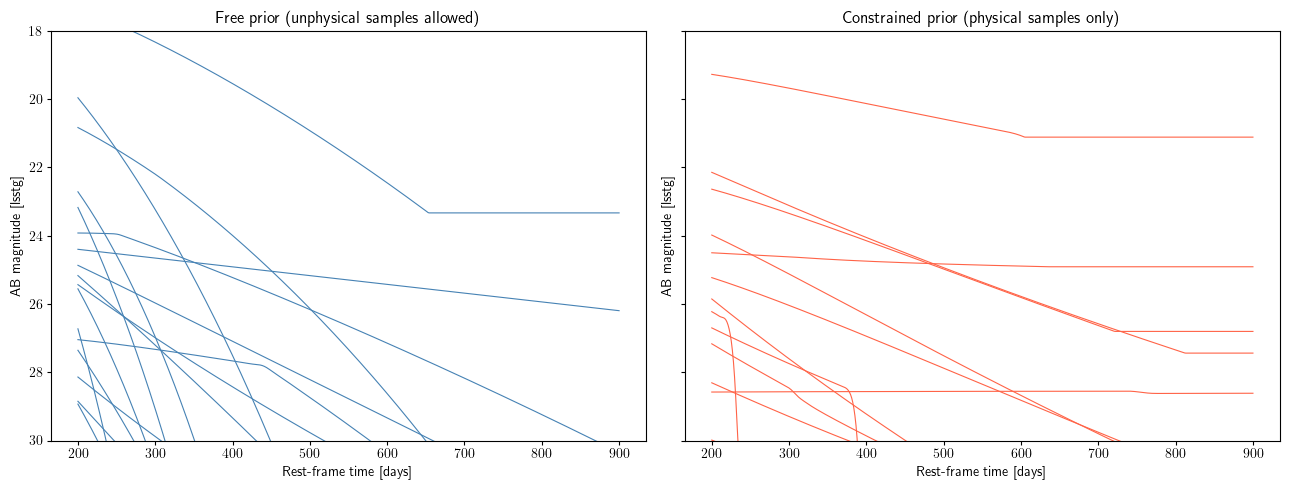

In [86]:
# --- Constraint priors: reject unphysical samples automatically ---
# csm_interaction has built-in physical constraints (photosphere, shock timing)
model_csm = 'csm_interaction'
func_csm = all_models_dict[model_csm]

# Without constraints
prior_free = redback.priors.get_priors(model=model_csm)
# With built-in physical constraints (bilby Constraint objects added automatically)
prior_csm  = redback.priors.get_priors(model=model_csm, constraint=True)

constraint_keys = [k for k, v in prior_csm.items()
                   if 'Constraint' in type(v).__name__]
print("Constraint keys added:", constraint_keys)

# Draw samples from both and compare the resulting light curves
t_csm = np.linspace(200, 900, 500)
samples_free = pd.DataFrame(prior_free.sample(30))
samples_csm  = pd.DataFrame(prior_csm.sample(30))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for i in range(len(samples_free)):
    kw_free = dict(samples_free.iloc[i])
    kw_free.update(output_format='magnitude', bands=['lsstg'])
    try:
        mag = func_csm(t_csm, **kw_free)
        axes[0].plot(t_csm, mag, c='steelblue', alpha=1, lw=0.8)
    except Exception:
        pass

for i in range(len(samples_csm)):
    kw_csm = dict(samples_csm.iloc[i])
    kw_csm.update(output_format='magnitude', bands=['lsstg'])
    try:
        mag = func_csm(t_csm, **kw_csm)
        axes[1].plot(t_csm, mag, c='tomato', alpha=1, lw=0.8)
    except Exception:
        pass

for ax, title in zip(axes, ['Free prior (unphysical samples allowed)',
                              'Constrained prior (physical samples only)']):
    ax.invert_yaxis(); ax.set_ylim(30, 18)
    ax.set_xlabel('Rest-frame time [days]'); ax.set_ylabel('AB magnitude [lsstg]')
    ax.set_title(title)
plt.tight_layout(); plt.show()

---
## 7. Inference

`redback.fit_model` wraps bilby sampling with automatic prior/likelihood selection, result saving, and plotting hooks.
A **fast demo fit** on simulated data runs in ~1–2 min with `nestle` + 100 live points.

See [`kilonova_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/kilonova_example.py),
[`magnetar_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/magnetar_example.py),
[`bolometric_luminosity_fitting.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/bolometric_luminosity_fitting.py),
[`magnetar_example_with_gaussian_process.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/magnetar_example_with_gaussian_process.py).


23:49 redback INFO    : Initializing Supernova transient 'demo_bolometric' with data_mode='luminosity'
23:49 redback INFO    : [Errno 2] No such file or directory: 'supernova//demo_bolometric_metadata.csv'
23:49 redback INFO    : Setting metadata to None. This is not an error, but a warning that no metadata could be found online.


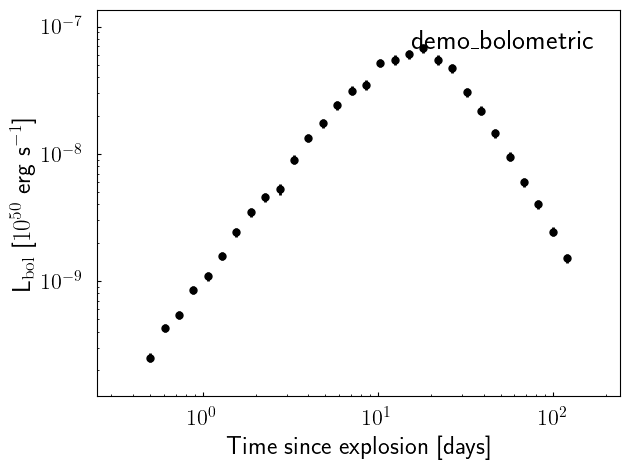

<Axes: xlabel='Time since explosion [days]', ylabel='L$_{\\rm bol}$ [$10^{50}$ erg s$^{-1}$]'>

In [108]:
# --- 7a. Fast demo fit on simulated luminosity data ---
# We simulate arnett bolometric luminosity data and fit it back.

np.random.seed(99)
func_bol = all_models_dict['arnett_bolometric']
times_bol = np.geomspace(0.5, 120, 30)
true_params_bol = dict(kappa=0.07, kappa_gamma=0.01, mej=3.1, vej=12000,
                        temperature_floor=2000, f_nickel=0.1)

lbol_true = func_bol(times_bol, **true_params_bol)
sigmas_bol = 0.08 * lbol_true
lbol_obs  = lbol_true + np.random.normal(0, sigmas_bol)

sn_bol = redback.transient.Supernova(
    name='demo_bolometric',
    data_mode='luminosity',
    time_rest_frame=times_bol,
    Lum50=lbol_obs / 1e50,
    Lum50_err=sigmas_bol / 1e50)

sn_bol.plot_data(save=False, show=True)

23:51 redback INFO    : No likelihood provided, using standard GaussianLikelihood
23:51 redback INFO    : No kwargs passed to function
23:51 bilby INFO    : Running for label 'demo_bolometric', output will be saved to 'supernova//arnett_bol_wrapper'
23:51 bilby INFO    : Analysis priors:
23:51 bilby INFO    : f_nickel=LogUniform(minimum=0.001, maximum=1, name='f_nickel', latex_label='$f_{\\mathrm{Ni}}$', unit=None, boundary=None)
23:51 bilby INFO    : mej=LogUniform(minimum=0.0001, maximum=5, name='mej', latex_label='$M_{\\mathrm{ej}}~(M_{\\odot})$', unit=None, boundary=None)
23:51 bilby INFO    : vej=LogUniform(minimum=1000.0, maximum=100000.0, name='vej', latex_label='$v_{\\mathrm{ej}}~(\\mathrm{km}/\\mathrm{s})$', unit=None, boundary=None)
23:51 bilby INFO    : kappa_gamma=LogUniform(minimum=0.0001, maximum=10000.0, name='kappa_gamma', latex_label='$\\kappa_{\\gamma}~(\\mathrm{cm}^{2}/\\mathrm{g})$', unit=None, boundary=None)
23:51 bilby INFO    : kappa=0.07
23:51 bilby INFO    : An

it=  7956 logz=583.91716527140


23:51 bilby INFO    : Sampling time: 0:00:09.833051
23:51 bilby INFO    : Summary of results:
nsamples: 8457
ln_noise_evidence: -1750.851
ln_evidence: 584.280 +/-  0.165
ln_bayes_factor: 2335.132 +/-  0.165

23:51 redback INFO    : Initializing Supernova transient 'demo_bolometric' with data_mode='luminosity'
23:51 redback INFO    : [Errno 2] No such file or directory: 'supernova//demo_bolometric_metadata.csv'
23:51 redback INFO    : Setting metadata to None. This is not an error, but a warning that no metadata could be found online.


Log evidence: 584.28 ± 0.17


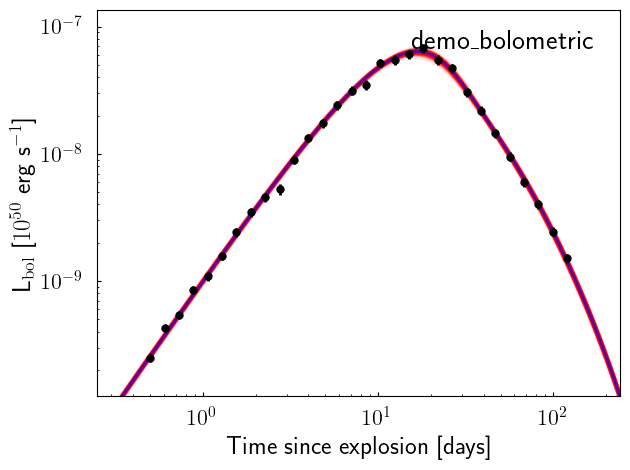

In [113]:
# Wrapper converts erg/s → 10^50 erg/s (Supernova transient convention)
def arnett_bol_wrapper(tt, **kwargs):
    return func_bol(tt, **kwargs) / 1e50

priors_bol = redback.priors.get_priors('arnett_bolometric')
priors_bol['kappa'] = true_params_bol['kappa']
priors_bol['mej'].maximum = 5

result_bol = redback.fit_model(
    transient=sn_bol,
    model=arnett_bol_wrapper,
    prior=priors_bol,
    sampler='nestle',
    nlive=500,
    plot=False,
    clean=True,
    injection_parameters=true_params_bol)

print(f"Log evidence: {result_bol.log_evidence:.2f} ± {result_bol.log_evidence_err:.2f}")
result_bol.plot_lightcurve(model=arnett_bol_wrapper, save=False, random_models=200)
plt.show()

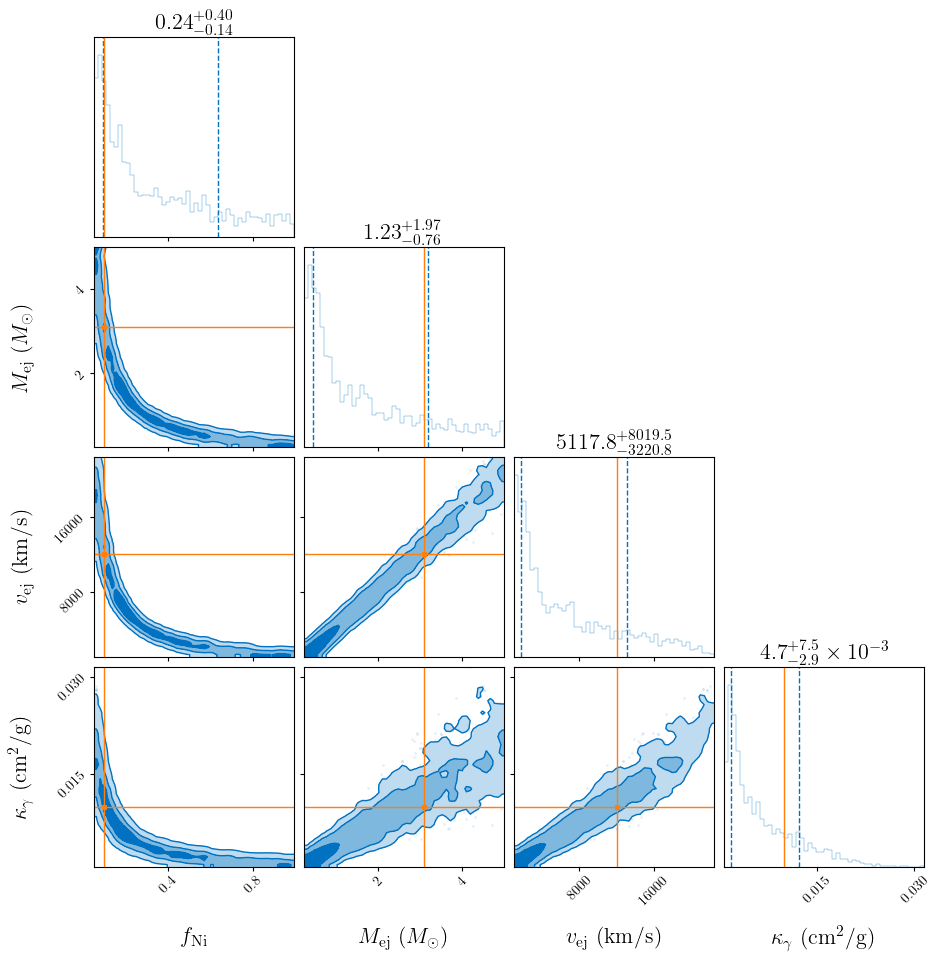

In [114]:
# Corner plot for the bolometric fit
result_bol.plot_corner(save=False)
plt.show()

---
## 8. Results

The `Result` object wraps bilby with redback-specific plotting. We load a pre-run result here to illustrate the interface at full posterior size.


In [115]:
import os
result_path = 'GRBData/afterglow/luminosity/evolving_magnetar/GRB070809_result.json'

if os.path.exists(result_path):
    result = redback.result.read_in_result(filename=result_path)
    print("Loaded pre-run result:", result_path)
else:
    # Fall back to the bolometric result from Section 7
    result = result_bol
    print("Using Section 7 bolometric fit result")

print(f"Posterior samples: {len(result.posterior)}")
print(f"Parameters: {list(result.posterior.columns)}")

23:51 redback INFO    : Loading result from file: GRBData/afterglow/luminosity/evolving_magnetar/GRB070809_result.json
23:51 redback INFO    : Successfully loaded result for 'GRB070809' (model: evolving_magnetar)


Loaded pre-run result: GRBData/afterglow/luminosity/evolving_magnetar/GRB070809_result.json
Posterior samples: 860
Parameters: ['a_1', 'alpha_1', 'p0', 'mu0', 'muinf', 'sinalpha0', 'tm', 'II', 'log_likelihood', 'log_prior']


In [121]:
print("=== Result attributes and methods ===\n")

for name in sorted(dir(result)):
    if name.startswith('_'):
        continue
    obj = getattr(type(result), name, None) or getattr(result, name, None)
    if isinstance(obj, property):
        print(f"  [property] {name}")
    elif callable(getattr(result, name)):
        try:
            sig = inspect.signature(getattr(result, name))
            print(f"  [method]   {name}{sig}")
        except (ValueError, TypeError):
            print(f"  [method]   {name}")
    else:
        val = getattr(result, name)
        print(f"  [attr]     {name} = {type(val).__name__}")

=== Result attributes and methods ===

  [property] bayesian_model_dimensionality
  [method]   calculate_prior_values(priors)
  [attr]     constraint_parameter_keys = list
  [property] covariance_matrix
  [attr]     fixed_parameter_keys = list
  [method]   from_hdf5(filename=None, outdir=None, label=None)
  [method]   from_json(filename=None, outdir=None, label=None, gzip=False)
  [method]   from_pickle(filename=None, outdir=None, label=None)
  [method]   get_all_injection_credible_levels(keys=None, weights=None)
  [method]   get_injection_credible_level(parameter, weights=None)
  [method]   get_latex_labels_from_parameter_keys(keys)
  [method]   get_one_dimensional_median_and_error_bar(key, fmt='.2f', quantiles=(0.16, 0.84))
  [method]   get_weights_by_new_prior(old_prior, new_prior, prior_names=None)
  [attr]     information_gain = float
  [attr]     injection_parameters = NoneType
  [property] kde
  [attr]     label = str
  [property] log_10_bayes_factor
  [property] log_10_evidence

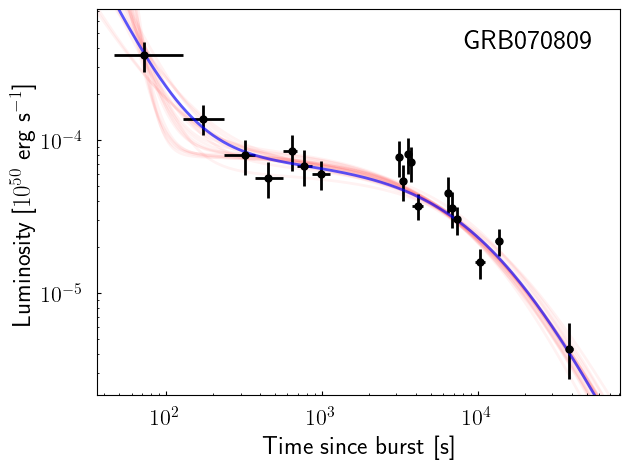

In [117]:
result.plot_lightcurve(random_models=20, save=False)
plt.show()

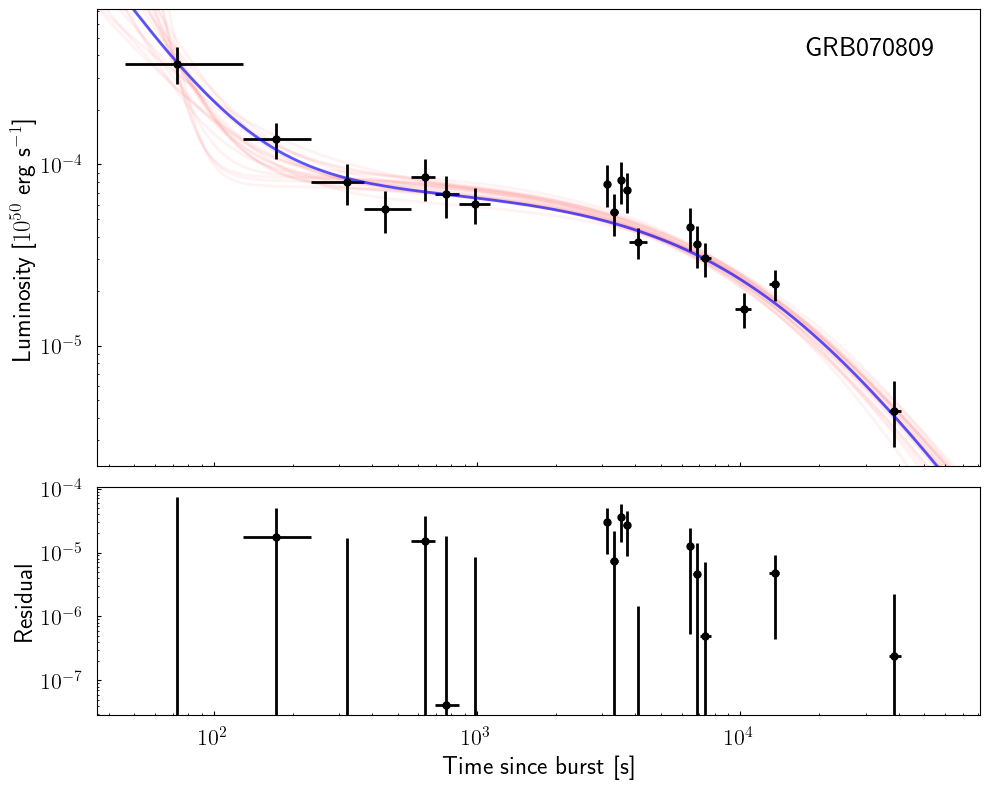

In [118]:
result.plot_residual(random_models=20, save=False)
plt.show()

---
## Summary & further examples

### All example scripts and notebooks

**Data download**
- [`getting_data_with_redback.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/getting_data_with_redback.py) — tour of all data downloaders: FINK, LASAIR, Swift, OSC, TNS
- [`get_fink_data.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/get_fink_data.py) — download and plot a ZTF transient from the FINK broker
- [`prompt_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/prompt_example.py) — download and fit BATSE GRB prompt emission data

**Transient objects**
- [`creating_transient_objects.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/creating_transient_objects.py) — all the ways to load transient objects from files, catalogues, or simulated data
- [`broadband_afterglow_private_data_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/broadband_afterglow_private_data_example.py) — fit GRB170817A broadband afterglow from a private CSV using the Afterglow object
- [`handling_non_detections.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/handling_non_detections.ipynb) — how redback handles upper limits in plotting and fitting
- [`BasicTutorial.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/BasicTutorial.ipynb) — introductory walkthrough of redback's core interface

**Blackbody & bolometric**
- [`estimating_blackbody_properties_with_redback.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/estimating_blackbody_properties_with_redback.ipynb) — fit standard and cutoff blackbody SEDs to photometry to get temperature and radius
- [`estimating_lbols.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/estimating_lbols.ipynb) — build a bolometric light curve from multi-band photometry

**Spectral analysis**
- [`analyse_spectrums.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/analyse_spectrums.ipynb) — fit spectral features (line profiles, velocities, classification)
- [`spectral_template_matching_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/spectral_template_matching_example.py) — SNID-style classification using SpectralTemplateMatcher against sncosmo libraries
- [`spectral_line_profile_models_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/spectral_line_profile_models_example.py) — P-Cygni profiles, Voigt absorption, photospheric velocity tracking
- [`joint_spectrum_photometry_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/joint_spectrum_photometry_example.py) — jointly fit a transient's spectrum and photometry with MultiMessengerTransient
- [`joint_galaxy_transient_spectrum_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/joint_galaxy_transient_spectrum_example.py) — simultaneously fit a transient and host galaxy spectrum
- [`fit_gamma_xray_spectra.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/fit_gamma_xray_spectra.py) — fit a gamma/X-ray count spectrum using a Band function
- [`fit_ogip_spectrum.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/fit_ogip_spectrum.py) — fit an OGIP PHA/RMF spectrum (Fermi/GBM BGO example data)

**Models as functions**
- [`using_model_as_a_function.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/using_model_as_a_function.py) — call any redback model directly as a Python function for plotting or exploration
- [`fit_your_own_model_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/fit_your_own_model_example.py) — pass a custom Python function as the model to fit_model
- [`using_sncosmo_models_to_fit.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/using_sncosmo_models_to_fit.py) — use any sncosmo model through redback's interface
- [`salt2_interface.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/salt2_interface.py) — SALT2 SN Ia template via the sncosmo interface
- [`create_your_own_ejecta_relation.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/create_your_own_ejecta_relation.py) — subclass the ejecta relation to inject custom NS physics into kilonova models

**Simulation**
- [`simulate_basic_transient.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_basic_transient.py) — SimulateGenericTransient: custom time grid, any model, Gaussian noise
- [`simulate_kilonova.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_kilonova.py) — simulate a kilonova with a user-built pointings table and SNR cuts
- [`simulate_single_transient_in_ztf.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_single_transient_in_ztf.py) — simulate a single transient through the real ZTF pointing database
- [`simulate_single_transient_in_rubin.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_single_transient_in_rubin.py) — simulate a single transient through the Rubin LSST 10-year baseline pointings
- [`simulate_kilonova_population.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_kilonova_population.py) — simulate a population of kilonovae through Rubin; plot detected events
- [`simulate_survey.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_survey.py) — SimulateFullOpticalSurvey: simulate 1 month of ZTF for a kilonova population with a merger rate
- [`simulate_with_cadence.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_with_cadence.py) — SimulateTransientWithCadence: SNR-based detections with user-defined cadence, no pointing table required
- [`simulate_population_modular.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_population_modular.py) — modular PopulationSynthesizer: generate parameters, apply detection criteria, infer rate separately
- [`simulate_population_synthesis.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_population_synthesis.py) — PopulationSynthesizer with rate evolution, redshift weighting, and selection effects
- [`simple_population_forecast.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simple_population_forecast.py) — forecast N detections without committing to a rate (rate_weighted_redshifts=False)
- [`simulate_radio_xray.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_radio_xray.py) — simulate GRB afterglow, TDE, and other transients at radio and X-ray frequencies
- [`simulate_radio_xray_cadence.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_radio_xray_cadence.py) — radio/X-ray follow-up campaign simulation with SimulateTransientWithCadence
- [`simulate_gamma_xray_spectra_ray.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/simulate_gamma_xray_spectra_ray.py) — simulate high-energy photon-counting data: TTE events and binned count spectra
- [`fit_simulated_high_energy_blackbody.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/fit_simulated_high_energy_blackbody.py) — end-to-end: simulate an X-ray blackbody spectrum and recover parameters
- [`ToOSimulations_with_redback.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/ToOSimulations_with_redback.ipynb) — Target-of-Opportunity survey planning: simulate follow-up observations of a transient alert

**Priors & likelihoods**
- [`calling_a_model_with_inbuilt_constraints.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/calling_a_model_with_inbuilt_constraints.py) — use built-in bilby Constraint priors to reject unphysical samples; compare constrained vs free draws
- [`non_detection_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/non_detection_example.py) — encode a flux upper limit as a prior constraint; compare constrained vs unconstrained prior draws
- [`MixtureModelLikelihoods.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/MixtureModelLikelihoods.py) — MixtureGaussianLikelihood for outlier-robust fitting; recover per-point outlier probabilities
- [`GP_tutorial_with_redback.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/GP_tutorial_with_redback.ipynb) — Gaussian process likelihood with george: fit structured residuals on top of a physical model

**Inference — transient types**
- [`kilonova_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/kilonova_example.py) — fit kilonova photometry with one_component_kilonova_model
- [`supernova_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/supernova_example.py) — fit a supernova light curve with the arnett model
- [`supernova_homologous_expansion_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/supernova_homologous_expansion_example.py) — supernova with homologous expansion; combine bolometric and multiband output
- [`supernova_with_unknown_explosion_date.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/supernova_with_unknown_explosion_date.py) — fit a supernova when explosion epoch is unknown using GaussianLikelihoodQuadratureNoise
- [`SN2011kl_sample_in_t0_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/SN2011kl_sample_in_t0_example.py) — sample over explosion epoch t0 and dust extinction for SN2011kl
- [`tde_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/tde_example.py) — fit PS18kh TDE data with tde_analytical
- [`magnetar_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/magnetar_example.py) — fit GRB070809 afterglow with evolving_magnetar model
- [`magnetar_boosted_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/magnetar_boosted_example.py) — magnetar model with boosted ejecta; dynesty sampler
- [`gaussianrise_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/gaussianrise_example.py) — Gaussian-rise Metzger model for a TDE; demonstrates constraint priors
- [`bolometric_luminosity_fitting.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/bolometric_luminosity_fitting.py) — fit bolometric luminosity data with arnett_bolometric; wrapper for unit conversion
- [`magnetar_example_with_gaussian_process.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/magnetar_example_with_gaussian_process.py) — magnetar model with a GP (george + Matern32) on residuals
- [`lightcurvelynx_inference_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/lightcurvelynx_inference_example.py) — simulate and fit kilonovae using the LightCurveLynx LSST simulator (requires lightcurvelynx)
- [`vegas_afterglow_tutorial.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/vegas_afterglow_tutorial.ipynb) — GRB afterglow fitting with VegasAfterglow models (requires vegasafterglow)
- [`RedbackPaperPlots.ipynb`](https://github.com/nikhil-sarin/redback/blob/master/examples/RedbackPaperPlots.ipynb) — reproduce figures from the redback paper; Colab-ready

**Joint & multi-messenger**
- [`joint_grb_gw_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/joint_grb_gw_example.py) — jointly analyse a GRB afterglow + GW signal from a BNS merger using a joint bilby likelihood
- [`joint_spectrum_photometry_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/joint_spectrum_photometry_example.py) — MultiMessengerTransient for simultaneous spectrum + photometry fitting
- [`joint_galaxy_transient_spectrum_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/joint_galaxy_transient_spectrum_example.py) — disentangle transient and host galaxy contributions in a joint spectral fit
- [`multimessenger_example.py`](https://github.com/nikhil-sarin/redback/blob/master/examples/multimessenger_example.py) — GW170817-like event: jointly fit optical kilonova + X-ray + radio afterglow

---

**Documentation**: https://redback.readthedocs.io
**GitHub**: https://github.com/nikhil-sarin/redback
**Paper**: [Sarin et al. 2024](https://arxiv.org/abs/2401.17765)
